In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("drgfreeman/rockpaperscissors")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/rockpaperscissors


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# SEED SETUP
SEED = 20240215  # Müəllimin verdiyi seed-i buraya yaz
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hazırkı cihaz: {device}")

Hazırkı cihaz: cuda


In [3]:
data_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Kaggle-dakı datasetin alt qovluğunu yoxlayırıq
data_path = '/kaggle/input/rockpaperscissors/rps-cv-images'
if not os.path.exists(data_path):
    data_path = '/kaggle/input/rockpaperscissors/rockpaperscissors/rps-cv-images'

full_dataset = datasets.ImageFolder(root=data_path, transform=data_transform)

# Dataseti 80% Train, 20% Test olaraq bölürük
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

print(f"Cəmi şəkil: {len(full_dataset)}, Train: {train_size}, Test: {test_size}")

Cəmi şəkil: 2188, Train: 1750, Test: 438


In [4]:
class RPSModel(nn.Module):
    def __init__(self, dropout_p=0.5):
        super(RPSModel, self).__init__()
        # BLOCK 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # BLOCK 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # BLOCK 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

In [5]:
def train_model(lr, batch_size, dropout):
    model = RPSModel(dropout_p=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    history = {'train_acc': [], 'test_acc': []}
    
    for epoch in range(10):
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_acc = 100 * correct / total
        
        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        test_acc = 100 * correct / total
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        print(f"Epoch {epoch+1}/10 - Test Acc: {test_acc:.2f}%")
        
    return model, history

print("--- Version 1 Başlayır ---")
model1, hist1 = train_model(lr=0.001, batch_size=32, dropout=0.5)

print("\n--- Version 2 (Option A) Başlayır ---")
model2, hist2 = train_model(lr=0.0001, batch_size=32, dropout=0.5)

--- Version 1 Başlayır ---
Epoch 1/10 - Test Acc: 92.24%
Epoch 2/10 - Test Acc: 95.66%
Epoch 3/10 - Test Acc: 96.58%
Epoch 4/10 - Test Acc: 97.95%
Epoch 5/10 - Test Acc: 97.95%
Epoch 6/10 - Test Acc: 98.40%
Epoch 7/10 - Test Acc: 98.40%
Epoch 8/10 - Test Acc: 97.49%
Epoch 9/10 - Test Acc: 98.17%
Epoch 10/10 - Test Acc: 97.72%

--- Version 2 (Option A) Başlayır ---
Epoch 1/10 - Test Acc: 86.30%
Epoch 2/10 - Test Acc: 89.73%
Epoch 3/10 - Test Acc: 94.06%
Epoch 4/10 - Test Acc: 94.06%
Epoch 5/10 - Test Acc: 96.12%
Epoch 6/10 - Test Acc: 96.12%
Epoch 7/10 - Test Acc: 97.26%
Epoch 8/10 - Test Acc: 97.03%
Epoch 9/10 - Test Acc: 97.72%
Epoch 10/10 - Test Acc: 96.12%


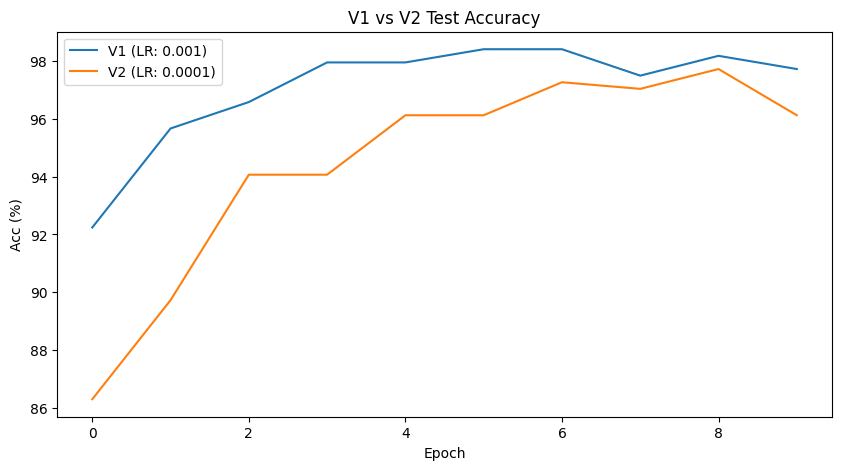


Version 1 Son Dəqiqlik: 97.72%
Version 2 Son Dəqiqlik: 96.12%


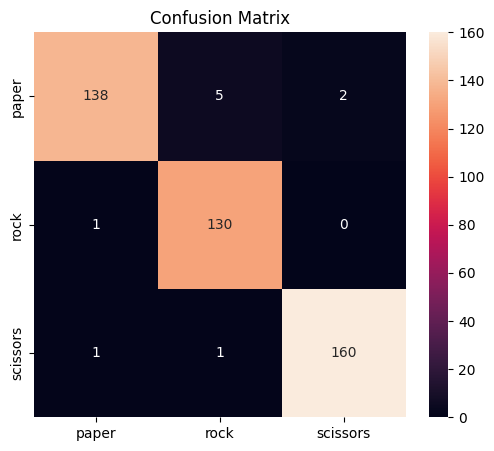

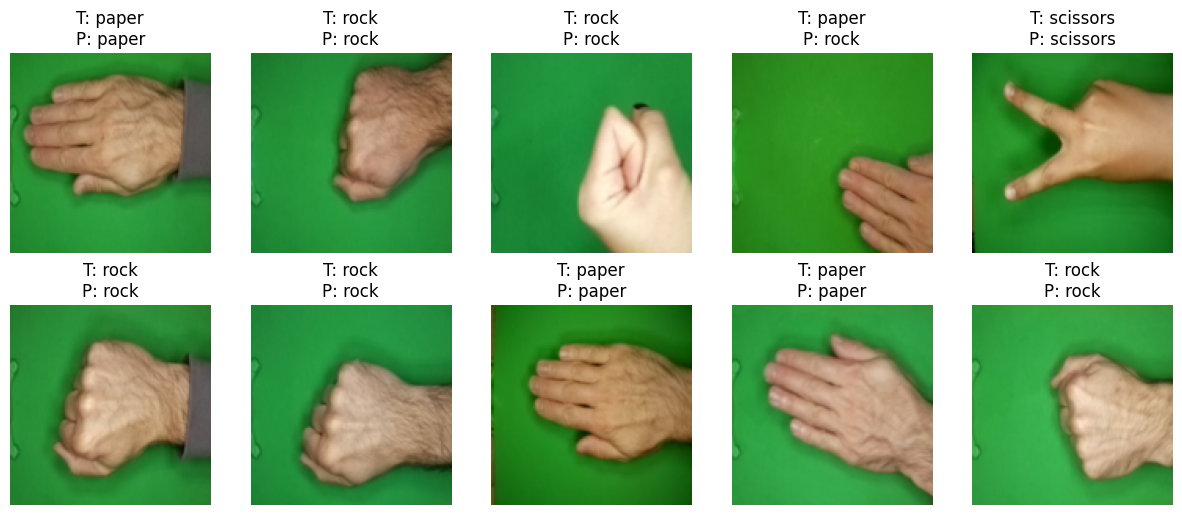

In [6]:
# 1. Comparison Plot
plt.figure(figsize=(10, 5))
plt.plot(hist1['test_acc'], label='V1 (LR: 0.001)')
plt.plot(hist2['test_acc'], label='V2 (LR: 0.0001)')
plt.title('V1 vs V2 Test Accuracy')
plt.ylabel('Acc (%)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# 2. Comparison Table
print(f"\nVersion 1 Son Dəqiqlik: {hist1['test_acc'][-1]:.2f}%")
print(f"Version 2 Son Dəqiqlik: {hist2['test_acc'][-1]:.2f}%")

# 3. Confusion Matrix (Best Model)
best_model = model1 if hist1['test_acc'][-1] > hist2['test_acc'][-1] else model2
y_true, y_pred = [], []
best_model.eval()
with torch.no_grad():
    for imgs, lbls in DataLoader(test_dataset, batch_size=32):
        outputs = best_model(imgs.to(device))
        _, preds = torch.max(outputs, 1)
        y_true.extend(lbls.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.title('Confusion Matrix')
plt.show()

# 4. 10 Sample Predictions
sample_loader = DataLoader(test_dataset, batch_size=10, shuffle=True)
imgs, lbls = next(iter(sample_loader))
outputs = best_model(imgs.to(device))
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    img = imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    plt.imshow(img)
    plt.title(f"T: {full_dataset.classes[lbls[i]]}\nP: {full_dataset.classes[preds[i]]}")
    plt.axis('off')
plt.show()